In [2]:
# define path to FVCOM data files
import xarray as xr
import os
FVCOM_DIR_2023 = '/mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2023/'
FVCOM_DIR_2024 = '/mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/'


filename_2023 = 'nos.lmhofs.fields.n000.20230801.t00z.nc'
filename_2024 = 'lmhofs.fields.n000.20240801.t00z.nc'

ds_2023 = xr.open_dataset(FVCOM_DIR_2023 + filename_2023, decode_times=False)
ds_2024 = xr.open_dataset(FVCOM_DIR_2024 + filename_2024, decode_times=False)

print(f"2023 dims: {ds_2023.dims}")

print(f"2024 dims: {ds_2024.dims}")


getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t00z.nc: Operation not supported


2023 dims: FrozenMappingWarningOnValuesAccess({'nele': 171377, 'node': 90806, 'siglay': 20, 'siglev': 21, 'three': 3, 'time': 1, 'maxnode': 11, 'maxelem': 9, 'four': 4})
2024 dims: FrozenMappingWarningOnValuesAccess({'nele': 171377, 'node': 90806, 'siglay': 20, 'siglev': 21, 'three': 3, 'time': 1, 'maxnode': 11, 'maxelem': 9, 'four': 4})


2023 time attrs: {'long_name': 'time', 'units': 'days since 2018-01-01 00:00:00', 'format': 'defined reference date', 'time_zone': 'UTC'}
2024 time attrs: {'standard_name': 'time', 'long_name': 'time', 'units': 'seconds since 1970-01-01 00:00:00', 'calendar': 'gregorian'}
2023 file date: 2023-07-31 18:00:00
2024 file date: 2024-08-01 00:00:00

Variables in both files: ['Itime', 'Itime2', 'Times', 'a1u', 'a2u', 'art1', 'art2', 'atmos_press', 'aw0', 'awx', 'awy', 'h', 'iint', 'kh', 'km', 'kq', 'l', 'nbe', 'nbsn', 'nbve', 'net_heat_flux', 'nprocs', 'ntsn', 'ntve', 'nv', 'omega', 'partition', 'q2', 'q2l', 'salinity', 'short_wave', 'tauc', 'temp', 'u', 'uwind_speed', 'v', 'viscofh', 'viscofm', 'vwind_speed', 'wet_cells', 'wet_cells_prev_ext', 'wet_cells_prev_int', 'wet_nodes', 'wet_nodes_prev_int', 'ww', 'x', 'xc', 'y', 'yc', 'zeta']

Only in 2023: []
Only in 2024: []

Δtemp: mean=1.335, min=-9.948, max=12.124


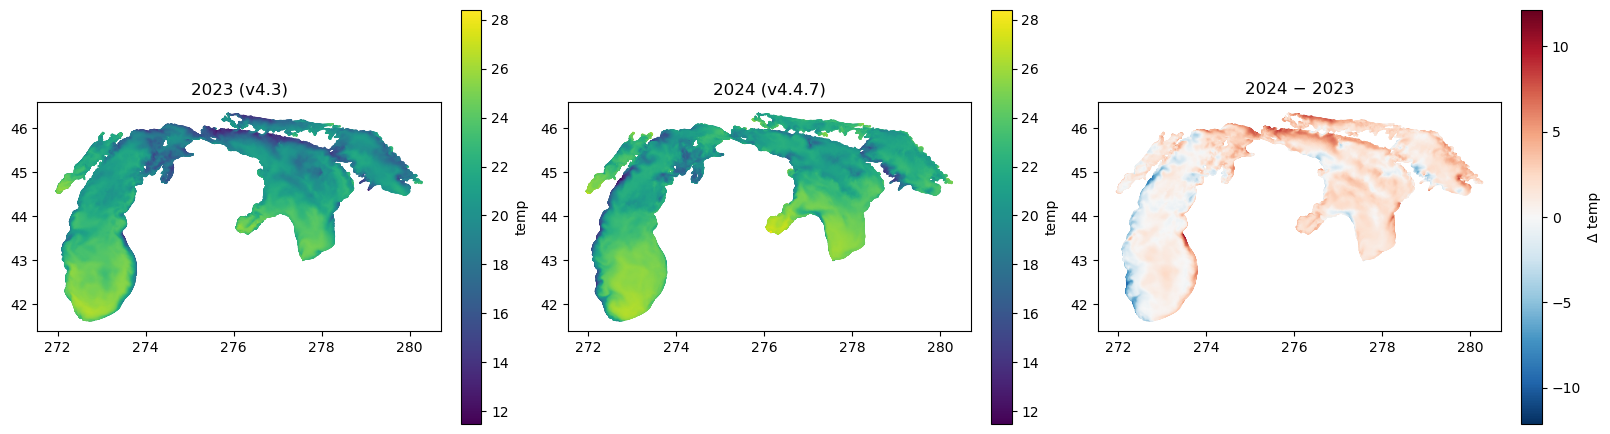

In [6]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import cftime

ds23 = ds_2023   # already opened with decode_times=False
ds24 = ds_2024

# ---------------------------------------------------------------
# 1. Confirm the mesh is truly identical
# ---------------------------------------------------------------
same_mesh = (
    ds23.sizes["node"] == ds24.sizes["node"]
    and ds23.sizes["nele"] == ds24.sizes["nele"]
    and np.allclose(ds23["lon"], ds24["lon"])
    and np.allclose(ds23["lat"], ds24["lat"])
)

# ---------------------------------------------------------------
# 2. Decode the timestamps so you KNOW what dates you're comparing
# ---------------------------------------------------------------
def get_date(ds):
    t = ds["time"]
    # --- Preferred: decode numeric time via its units attribute ---
    units = t.attrs.get("units")
    cal   = t.attrs.get("calendar", "standard")
    if units:
        try:
            return str(cftime.num2date(np.asarray(t).ravel()[0], units, cal))
        except Exception:
            pass
    # --- Fallback: parse the 'Times' character variable robustly ---
    if "Times" in ds.variables:
        v = np.asarray(ds["Times"].values)
        row = v[0] if v.ndim > 1 else v          # first timestep's char row
        row = row.ravel()
        try:
            if row.dtype.kind in ("S", "a"):                  # bytes
                return b"".join(row.tolist()).decode("utf-8", "ignore").strip()
            if row.dtype.kind in ("i", "u"):                  # char codes (your case)
                return bytes(int(x) for x in row).decode("utf-8", "ignore").strip()
            return "".join(str(x) for x in row).strip()       # unicode
        except Exception as e:
            return f"(Times parse failed: {e})"
    return f"raw time = {float(np.asarray(t).ravel()[0])} (no units attr)"


print("2023 time attrs:", dict(ds23["time"].attrs))
print("2024 time attrs:", dict(ds24["time"].attrs))
print("2023 file date:", get_date(ds23))
print("2024 file date:", get_date(ds24))
# ---------------------------------------------------------------
# 3. Which variables can actually be compared (common to both)?
# ---------------------------------------------------------------
common = sorted(set(ds23.data_vars) & set(ds24.data_vars))
print("\nVariables in both files:", common)
print("\nOnly in 2023:", sorted(set(ds23.data_vars) - set(ds24.data_vars)))
print("Only in 2024:", sorted(set(ds24.data_vars) - set(ds23.data_vars)))

# ---------------------------------------------------------------
# 4. Compute a difference for one node-based variable
#    (temp surface layer shown; use zeta/salinity/aice similarly)
# ---------------------------------------------------------------
var   = "temp"     # change to "zeta", "salinity", "aice", ...
layer = 0          # surface sigma layer; omit for 2D vars like zeta

def field(ds, var, layer):
    a = ds[var].isel(time=0)
    if "siglay" in a.dims:
        a = a.isel(siglay=layer)
    return a.values.astype(float)

f23 = field(ds23, var, layer)
f24 = field(ds24, var, layer)
diff = f24 - f23   # 2024 minus 2023, per node

print(f"\nΔ{var}: mean={np.nanmean(diff):.3f}, "
      f"min={np.nanmin(diff):.3f}, max={np.nanmax(diff):.3f}")

# ---------------------------------------------------------------
# 5. Visualize: side-by-side + difference on the triangular mesh
# ---------------------------------------------------------------
lon = ds23["lon"].values
lat = ds23["lat"].values
nv  = ds23["nv"].values.T.astype(int) - 1     # (nele,3), FVCOM is 1-based
tri = mtri.Triangulation(lon, lat, nv)

fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)

# matched color scale for the two snapshots
vmin = np.nanmin([f23, f24]); vmax = np.nanmax([f23, f24])
for ax, data, ttl in zip(axes[:2], [f23, f24], ["2023 (v4.3)", "2024 (v4.4.7)"]):
    tpc = ax.tripcolor(tri, data, shading="gouraud", cmap="viridis",
                       vmin=vmin, vmax=vmax)
    fig.colorbar(tpc, ax=ax, shrink=0.7, label=var)
    ax.set_title(ttl); ax.set_aspect("equal")

# difference: diverging map centered on zero (a signed field)
lim = np.nanmax(np.abs(diff))
tpc = axes[2].tripcolor(tri, diff, shading="gouraud", cmap="RdBu_r",
                        vmin=-lim, vmax=lim)
fig.colorbar(tpc, ax=axes[2], shrink=0.7, label=f"Δ {var}")
axes[2].set_title("2024 − 2023"); axes[2].set_aspect("equal")

plt.savefig("lmhofs_diff.png", dpi=200, bbox_inches="tight")
plt.show()

2023: 247 files | 2024: 124 files


getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t00z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t06z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t12z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t18z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240802.t00z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240802.t06z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240802.t12z.nc: Operation

Averaged 247 (2023) and 124 (2024) files

Δtemp  mean=0.782  median=0.855  std=0.915  RMS=1.204
5th–95th pct: -0.82 to 2.32 | % warmer in 2024: 80.5%


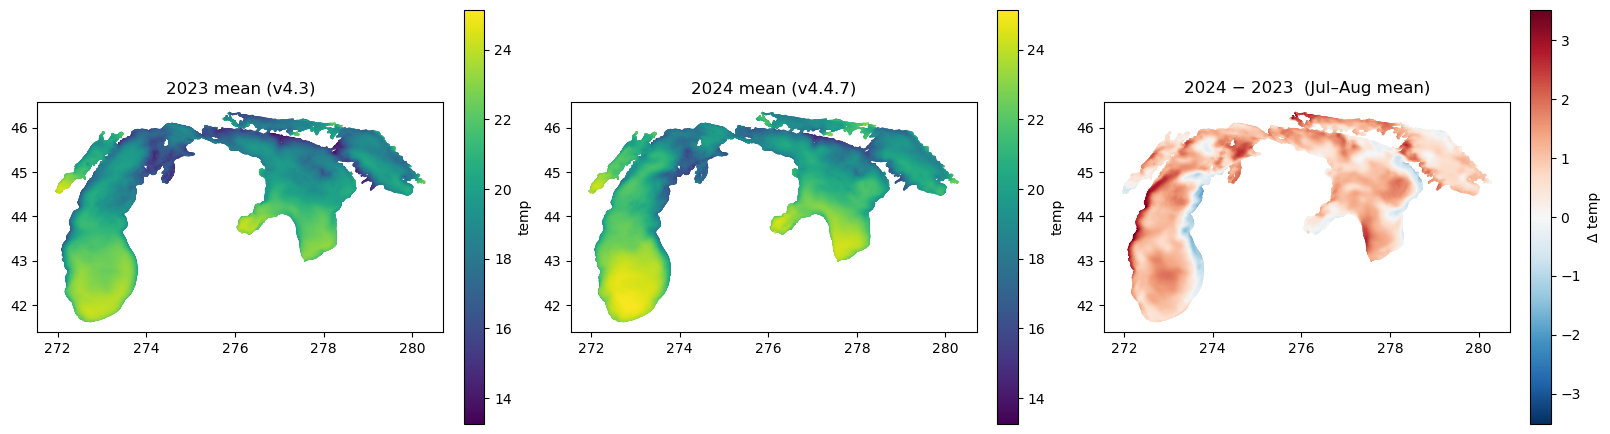

In [7]:
import os, glob, re
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.tri as mtri

# ----------------- configure -----------------
FVCOM_DIR_2023 = '/mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2023/'
FVCOM_DIR_2024 = '/mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/'
MONTHS = [7, 8]      # July–August; matched window in BOTH years
VAR    = "temp"      # "temp","salinity","zeta","aice",...
LAYER  = 0           # surface sigma layer (ignored for 2D vars like zeta)
FILL   = 1e20        # values above this magnitude treated as fill/nodata
# ----------------------------------------------

def list_field_files(directory, months=None, nowcast_only=True):
    """Field (gridded) nowcast files within the given months, any naming convention."""
    out = []
    for f in sorted(glob.glob(os.path.join(directory, "*.nc"))):
        name = os.path.basename(f)
        if "fields" not in name:               # skip station files
            continue
        if nowcast_only and ".n" not in name:  # skip forecast (f###) files
            continue
        m = re.search(r"(20\d{6})", name)       # find YYYYMMDD anywhere in name
        if not m:
            continue
        if months and int(m.group(1)[4:6]) not in months:
            continue
        out.append(f)
    return out

def streaming_mean(files, var, layer=0, fill=1e20):
    """Per-node mean over many files without loading them all at once."""
    ssum = scount = None
    used = 0
    for f in files:
        with xr.open_dataset(f, decode_times=False) as ds:
            if var not in ds.variables:
                continue
            a = ds[var].isel(time=0)
            if "siglay" in a.dims:
                a = a.isel(siglay=layer)
            v = a.values.astype("float64")
        v = np.where(np.abs(v) > fill, np.nan, v)
        if ssum is None:
            ssum   = np.zeros_like(v)
            scount = np.zeros_like(v)
        good = np.isfinite(v)
        ssum[good]   += v[good]
        scount[good] += 1
        used += 1
    mean = np.divide(ssum, scount, out=np.full_like(ssum, np.nan), where=scount > 0)
    return mean, used

# ---- gather files & confirm balanced sampling ----
files23 = list_field_files(FVCOM_DIR_2023, MONTHS)
files24 = list_field_files(FVCOM_DIR_2024, MONTHS)
print(f"2023: {len(files23)} files | 2024: {len(files24)} files")
if not files23 or not files24:
    raise SystemExit("No matching files — check the directory paths / naming.")

mean23, n23 = streaming_mean(files23, VAR, LAYER, FILL)
mean24, n24 = streaming_mean(files24, VAR, LAYER, FILL)
print(f"Averaged {n23} (2023) and {n24} (2024) files")
diff = mean24 - mean23

# ---- grid (read once from any file) ----
with xr.open_dataset(files23[0], decode_times=False) as g:
    lon = g["lon"].values; lat = g["lat"].values
    nv  = g["nv"].values.T.astype(int) - 1     # 1-based -> 0-based
tri = mtri.Triangulation(lon, lat, nv)

# ---- quantitative summary ----
d = diff[np.isfinite(diff)]
print(f"\nΔ{VAR}  mean={d.mean():.3f}  median={np.median(d):.3f}  "
      f"std={d.std():.3f}  RMS={np.sqrt((d**2).mean()):.3f}")
print(f"5th–95th pct: {np.percentile(d,5):.2f} to {np.percentile(d,95):.2f} | "
      f"% warmer in 2024: {100*(d>0).mean():.1f}%")

# ---- 3-panel map ----
fig, axes = plt.subplots(1, 3, figsize=(16, 6), constrained_layout=True)
vmin = np.nanmin([mean23, mean24]); vmax = np.nanmax([mean23, mean24])
for ax, data, ttl in zip(axes[:2], [mean23, mean24],
                         [f"2023 mean (v4.3)", f"2024 mean (v4.4.7)"]):
    tpc = ax.tripcolor(tri, data, shading="gouraud", cmap="viridis",
                       vmin=vmin, vmax=vmax)
    fig.colorbar(tpc, ax=ax, shrink=0.7, label=VAR)
    ax.set_title(ttl); ax.set_aspect("equal")

lim = np.nanmax(np.abs(diff))
tpc = axes[2].tripcolor(tri, diff, shading="gouraud", cmap="RdBu_r",
                        vmin=-lim, vmax=lim)
fig.colorbar(tpc, ax=axes[2], shrink=0.7, label=f"Δ {VAR}")
axes[2].set_title(f"2024 − 2023  (Jul–Aug mean)"); axes[2].set_aspect("equal")
plt.savefig("lmhofs_monthly_diff.png", dpi=200, bbox_inches="tight")
plt.show()

common calendar days: 31 (0801–0831) | 123 (2023) vs 124 (2024) files


getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t00z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t06z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t12z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240801.t18z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240802.t00z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240802.t06z.nc: Operation not supported
getfattr: /mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/lmhofs.fields.n000.20240802.t12z.nc: Operation

|Δ mean V|: median=0.0168  mean=0.0254  95th=0.0756 m/s
median |Δ mean V| is ~62% of the median residual speed
saved → FigS_current_vector_diff.png


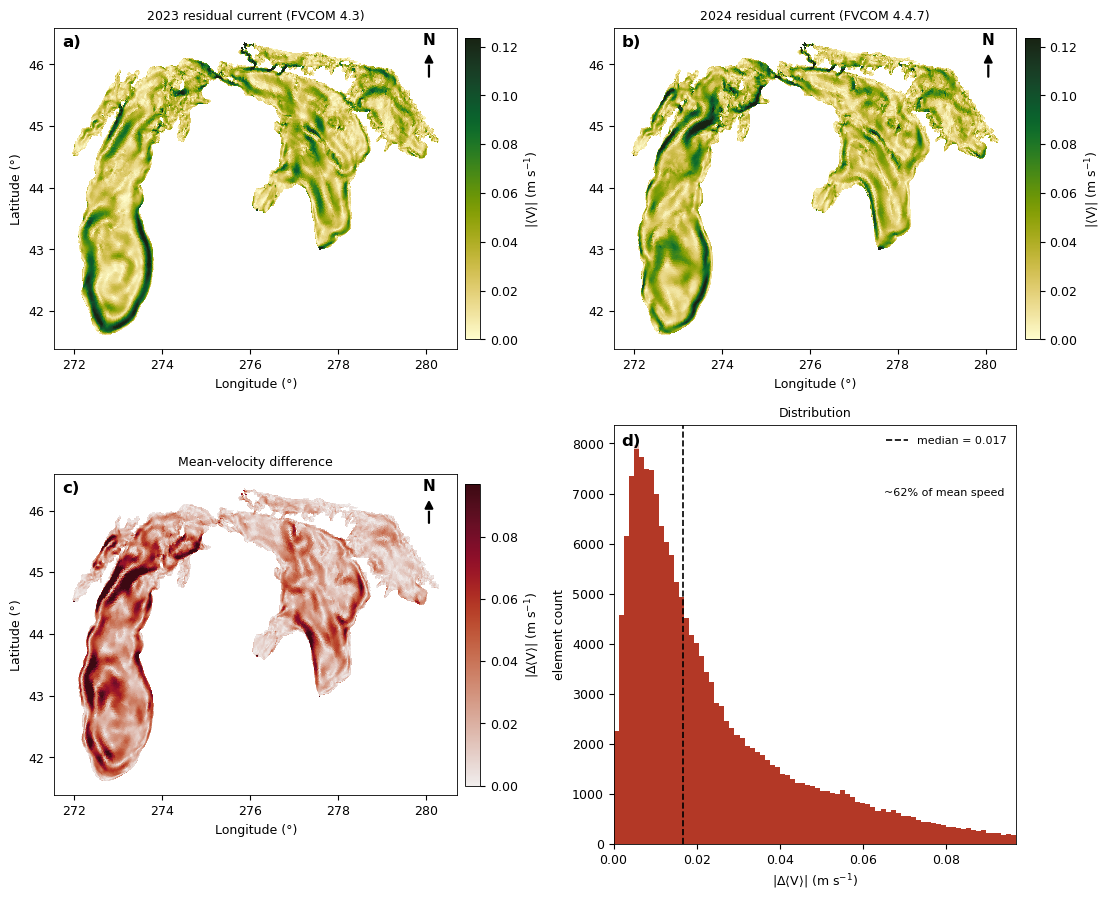

In [8]:
import os, glob, re
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import matplotlib.patheffects as pe

DIR_2023 = '/mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2023/'
DIR_2024 = '/mnt/hydroglg/Data/External_Models/Outputs/GLCFS/LakeHuron/2024_corrected/'
MONTHS   = [7, 8]
LAYER    = 0
FILL     = 1e20
OUT      = "FigS_current_vector_diff.png"
mpl.rcParams.update({'font.size': 9, 'font.family': 'sans-serif', 'axes.linewidth': 0.6})

# ---- index files by MONTH-DAY so the same calendar day matches across years ----
def files_by_mmdd(directory, months=None):
    d = {}
    for f in sorted(glob.glob(os.path.join(directory, "*.nc"))):
        name = os.path.basename(f)
        if "fields" not in name or ".n000." not in name:   # one nowcast per cycle
            continue
        m = re.search(r"(20\d{6})", name)                    # YYYYMMDD
        if not m:
            continue
        ymd = m.group(1)
        if months and int(ymd[4:6]) not in months:
            continue
        d.setdefault(ymd[4:8], []).append(f)                 # key = MMDD
    return d

by23, by24 = files_by_mmdd(DIR_2023, MONTHS), files_by_mmdd(DIR_2024, MONTHS)
common = sorted(set(by23) & set(by24))                       # matched calendar days
if not common:
    raise SystemExit("No overlapping calendar days — check months / directories.")

files23 = [f for mmdd in common for f in by23[mmdd]]
files24 = [f for mmdd in common for f in by24[mmdd]]
print(f"common calendar days: {len(common)} ({common[0]}–{common[-1]}) | "
      f"{len(files23)} (2023) vs {len(files24)} (2024) files")

# ---- streaming mean of the velocity VECTOR (mean u, mean v per element) ----
def mean_uv(files, layer=0, fill=1e20):
    su = sv = cnt = None
    for f in files:
        with xr.open_dataset(f, decode_times=False) as ds:
            if "u" not in ds.variables:
                continue
            u = ds["u"].isel(time=0); v = ds["v"].isel(time=0)
            if "siglay" in u.dims:
                u = u.isel(siglay=layer); v = v.isel(siglay=layer)
            uu = u.values.astype("float64"); vv = v.values.astype("float64")
        bad = (np.abs(uu) > fill) | (np.abs(vv) > fill)
        uu[bad] = np.nan; vv[bad] = np.nan
        if su is None:
            su = np.zeros_like(uu); sv = np.zeros_like(uu); cnt = np.zeros_like(uu)
        good = np.isfinite(uu) & np.isfinite(vv)
        su[good] += uu[good]; sv[good] += vv[good]; cnt[good] += 1
    mu = np.divide(su, cnt, out=np.full_like(su, np.nan), where=cnt > 0)
    mv = np.divide(sv, cnt, out=np.full_like(sv, np.nan), where=cnt > 0)
    return mu, mv

mu23, mv23 = mean_uv(files23, LAYER, FILL)
mu24, mv24 = mean_uv(files24, LAYER, FILL)

res23 = np.hypot(mu23, mv23)                  # residual (mean) current speed
res24 = np.hypot(mu24, mv24)
vecdiff = np.hypot(mu24 - mu23, mv24 - mv23)  # |Δ mean velocity| — transport-relevant

# ---- grid ----
with xr.open_dataset(files23[0], decode_times=False) as g:
    lon = g["lon"].values; lat = g["lat"].values
    nv  = g["nv"].values.T.astype(int) - 1
tri = mtri.Triangulation(lon, lat, nv)

# ---- stats for caption ----
vd = vecdiff[np.isfinite(vecdiff)]
rs = res23[np.isfinite(res23)]
rel = 100 * np.nanmedian(vecdiff) / np.nanmedian(res23)
print(f"|Δ mean V|: median={np.median(vd):.4f}  mean={vd.mean():.4f}  "
      f"95th={np.percentile(vd,95):.4f} m/s")
print(f"median |Δ mean V| is ~{rel:.0f}% of the median residual speed")

# ---- figure ----
fig, axes = plt.subplots(2, 2, figsize=(11, 9.2), constrained_layout=True)
aspect = 1.0 / np.cos(np.deg2rad(np.nanmean(lat)))

def north_arrow(ax, x=0.93, y0=0.84, y1=0.93):
    ax.annotate("", xy=(x, y1), xytext=(x, y0), xycoords="axes fraction",
                arrowprops=dict(arrowstyle="-|>", color="k", lw=1.6, mutation_scale=12,
                                path_effects=[pe.withStroke(linewidth=3, foreground="white")]),
                annotation_clip=False, zorder=1001)
    ax.text(x, y1+0.01, "N", transform=ax.transAxes, ha="center", va="bottom",
            fontsize=11, fontweight="bold", zorder=1002,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.4))

try:
    import cmocean
    cmap_speed, cmap_mag = cmocean.cm.speed, cmocean.cm.amp
except ImportError:
    cmap_speed, cmap_mag = plt.cm.viridis, plt.cm.magma_r

vmax = np.nanpercentile(np.r_[res23[np.isfinite(res23)], res24[np.isfinite(res24)]], 98)
for ax, data, ttl in zip([axes[0,0], axes[0,1]], [res23, res24],
                         ["2023 residual current (FVCOM 4.3)", "2024 residual current (FVCOM 4.4.7)"]):
    tpc = ax.tripcolor(tri, facecolors=data, cmap=cmap_speed, vmin=0, vmax=vmax)
    fig.colorbar(tpc, ax=ax, shrink=0.72, pad=0.02).set_label(r"|$\langle$V$\rangle$| (m s$^{-1}$)")
    ax.set_title(ttl, fontsize=9); ax.set_aspect(aspect); ax.set_xlabel("Longitude (°)"); north_arrow(ax)
axes[0,0].set_ylabel("Latitude (°)")

axm = axes[1,0]
mmax = np.nanpercentile(vd, 98)
tpc = axm.tripcolor(tri, facecolors=vecdiff, cmap=cmap_mag, vmin=0, vmax=mmax)
fig.colorbar(tpc, ax=axm, shrink=0.72, pad=0.02).set_label(r"|$\Delta\langle$V$\rangle$| (m s$^{-1}$)")
axm.set_title("Mean-velocity difference", fontsize=9)
axm.set_aspect(aspect); axm.set_xlabel("Longitude (°)"); axm.set_ylabel("Latitude (°)"); north_arrow(axm)

axh = axes[1,1]
axh.hist(vd, bins=80, range=(0, mmax), color=cmap_mag(0.6), edgecolor="none")
axh.axvline(np.median(vd), color="k", ls="--", lw=1.2, label=f"median = {np.median(vd):.3f}")
axh.set_xlim(0, mmax); axh.set_xlabel(r"|$\Delta\langle$V$\rangle$| (m s$^{-1}$)")
axh.set_ylabel("element count"); axh.set_title("Distribution", fontsize=9)
axh.legend(fontsize=8, frameon=False)
axh.text(0.97, 0.85, f"~{rel:.0f}% of mean speed", transform=axh.transAxes,
         ha="right", va="top", fontsize=8)

for ax, lab in zip([axes[0,0], axes[0,1], axes[1,0], axes[1,1]], ["a)","b)","c)","d)"]):
    ax.text(0.02, 0.98, lab, transform=ax.transAxes, ha="left", va="top",
            fontsize=12, fontweight="bold",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.3))

fig.savefig(OUT, dpi=300, bbox_inches="tight")
print("saved →", OUT)
plt.show()